# Networks Analysis

In [1]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import os
from matplotlib.colors import Normalize, TwoSlopeNorm

### Choose the networks to analyse

In [2]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base2_"

### Create folder and paths

In [3]:
# Create analysis output directory and logging file
analysis_dir = f"{home}/pypsa-eur/analysis/{folder}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "summary.txt")

# Initialize/clear the log file with header
with open(log_file, "w") as _f:
    _f.write(f"Networks comparison summary\n")

def log_print(*args, sep=' ', end='\n', also_print=True):
    """Helper to print and append to the summary log"""
    s = sep.join(str(a) for a in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, 'a') as _f:
        _f.write(s)

def save_fig(fig, name, dpi=150):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(analysis_dir, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    log_print(f"Saved figure: {fname}")

### Set paths

In [4]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [5]:
carrier_display_names = {
    "onwind": "Onshore wind",
    "offwind-ac": "Offshore wind (AC)",
    "offwind-float": "Offshore wind (floating)",
    "solar": "Solar PV",
    "solar-hsat": "Solar PV (high satellite)",
    "hydro": "Hydro",
    "ror": "Run-of-river",
    "lignite": "Lignite",
    "coal": "Coal",
    "oil": "Oil",
    "OCGT": "OCGT",
    "CCGT": "CCGT",
    "biomass": "Biomass",
    "waste": "Waste",
    "geothermal": "Geothermal",
    "load": "Unserved Load",
    "battery discharge": "Battery discharge",
}

def carrier_label(name):
    return carrier_display_names.get(name, name)

## Check

### Installed capacities 

In [6]:
component_specs = [("generators", "p_nom_opt"), ("storage_units", "p_nom_opt"), ("links", "p_nom_opt")]

for network_name, network in networks.items():
    carrier_capacity = pd.Series(dtype=float)

    for component_name, capacity_column in component_specs:
        component = getattr(network, component_name, None)
        if component is None or component.empty or "carrier" not in component.columns or capacity_column not in component.columns:
            continue
        carrier_capacity = carrier_capacity.add(component.groupby("carrier")[capacity_column].sum(), fill_value=0)

    carrier_capacity = carrier_capacity.sort_values(ascending=False)
    print(f"\n{network.name} installed capacity by carrier [MW]")
    if carrier_capacity.empty:
        print("  No carrier capacity found.")
    else:
        print(carrier_capacity.to_string(float_format=lambda value: f"{value:.2f}"))


Windy installed capacity by carrier [MW]
carrier
load                      inf
solar                86408.00
onwind               73332.07
CCGT                 30783.13
coal                 20351.94
lignite              19457.03
offwind-ac           11163.74
biomass               8020.00
PHS                   7361.72
OCGT                  6112.74
oil                   5684.35
ror                   4014.12
waste                 3127.66
battery discharger    1214.43
battery charger       1189.89
hydro                  402.24
geothermal              26.90
H2 Electrolysis          0.03
H2 Fuel Cell             0.02
offwind-float            0.00
offwind-dc               0.00
solar-hsat               0.00

Not Windy installed capacity by carrier [MW]
carrier
load                      inf
solar                86408.00
onwind               73332.07
CCGT                 30783.13
coal                 20351.94
lignite              19457.03
offwind-ac           11163.74
battery discharger    8846

### Line extension

In [7]:
for network in networks.values():
    log_print(f"\n{network.name} line capacities:")
    if "s_nom_opt" in network.lines and not network.lines.s_nom.equals(network.lines.s_nom_opt):
        log_print("  Line extension detected: 's_nom_opt' differs from 's_nom'.")
    else:
        log_print("  No line extension detected")


Windy line capacities:
  No line extension detected

Not Windy line capacities:
  No line extension detected

Wind Variability line capacities:
  No line extension detected


### Coal price 

In [8]:
carrier_name = "coal"

for network in networks.values():
    if hasattr(network, "generators"):
        g = network.generators
        if "carrier" in g.columns and "marginal_cost" in g.columns:
            mask = g["carrier"] == carrier_name
            if mask.any():
                original_costs = g.loc[mask, "marginal_cost"].copy()
                print(f"Marginal costs for '{carrier_name}' generators in {network.name} from {original_costs.iloc[0]:.2f}")
            else:
                print(f"No '{carrier_name}' generators found to modify costs.")

Marginal costs for 'coal' generators in Windy from 21.98
Marginal costs for 'coal' generators in Not Windy from 21.98
Marginal costs for 'coal' generators in Wind Variability from 21.98


### Components

In [9]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            log_print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Not Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Wind Variability
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900


### Grid Congestion and Curtailment

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/line_congestion.png


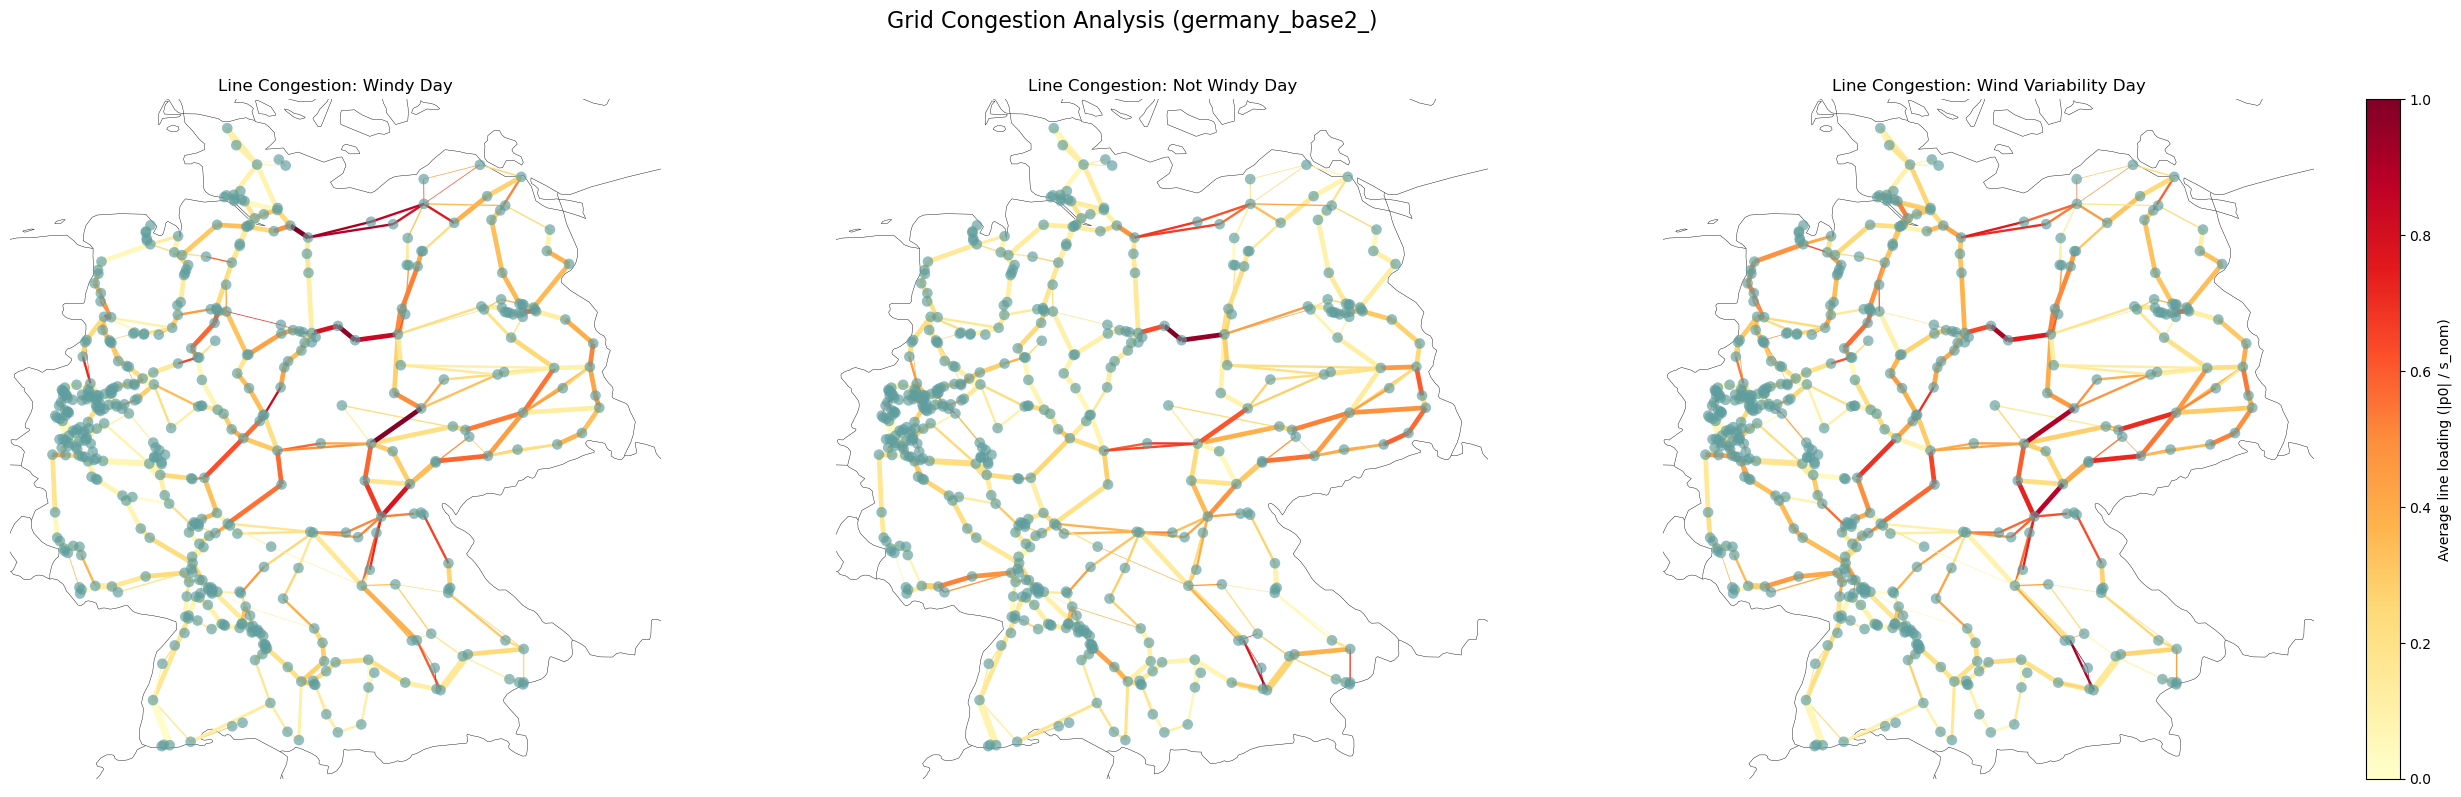

In [10]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Grid Congestion Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="YlOrRd",
        link_alpha=0.3,
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )
    return avg_loading_n, avg_loading_links

# Plot Average Loading Over All Snapshots for each network
line_loading_series = []
link_loading_series = []
i = 0
for n in networks.values():
    avg_loading_n, avg_loading_links = plot_network_congestion(
        n,
        axes[i],
        "Line Congestion: " + n.name + " Day",
    )
    line_loading_series.append(avg_loading_n)
    link_loading_series.append(avg_loading_links)
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Add a legend-like colorbar for line loading.
line_max = max(1.0, max(series.max() for series in line_loading_series if not series.empty))
line_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=line_max), cmap=plt.get_cmap("YlOrRd"))
line_mappable.set_array([])
cbar_line = fig.colorbar(line_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
cbar_line.set_label("Average line loading (|p0| / s_nom)")

# Add a second colorbar for link loading.
#link_max = max(1.0, max(series.max() for series in link_loading_series if not series.empty))
#link_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=link_max), cmap=plt.get_cmap("YlOrRd"))
#link_mappable.set_array([])
#cbar_link = fig.colorbar(link_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.12)
#bar_link.set_label("Average link loading (|p0| / p_nom)")

save_fig(fig, "line_congestion.png")

### Most extended lines 

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/line_link_extension.png


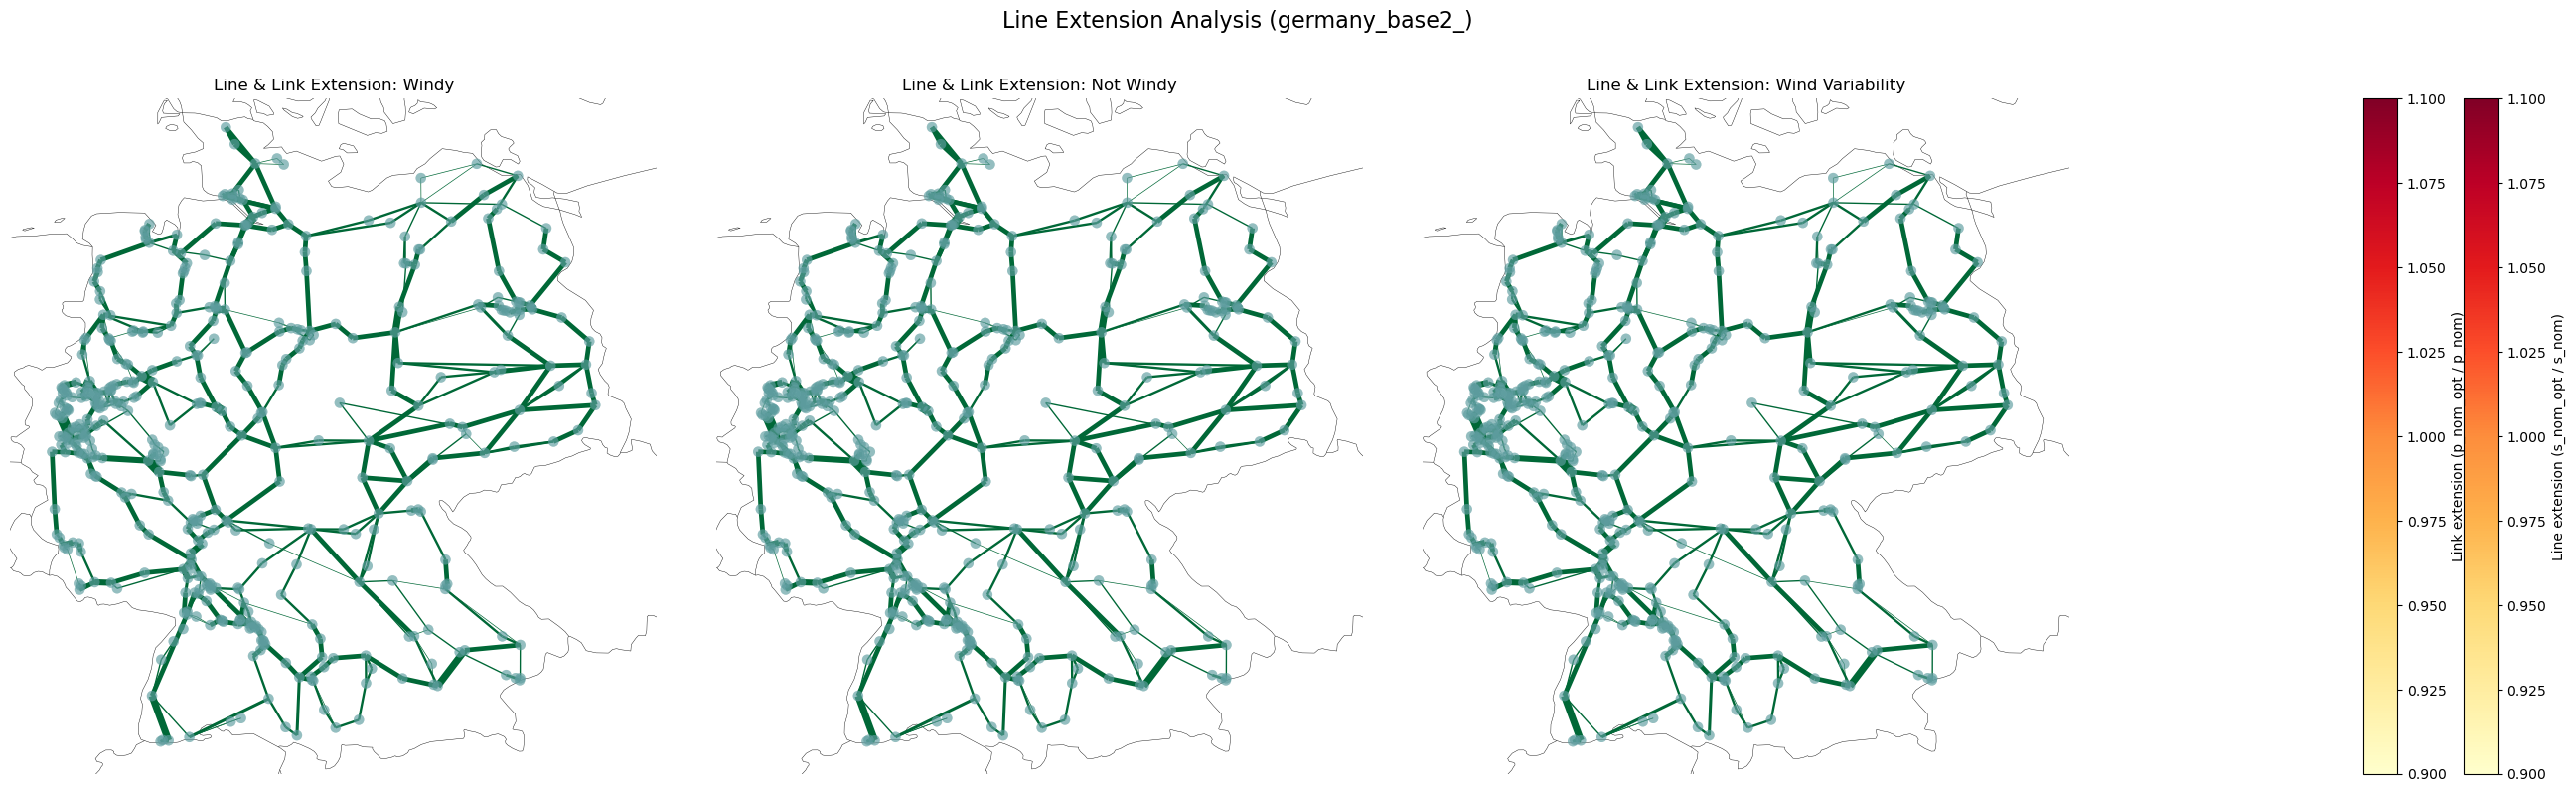

In [11]:
# --- Line Extension Visualization (new) ---
# This cell plots line extension defined as s_nom_opt / s_nom
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Line Extension Analysis ({folder})", fontsize=16)

# Helper to plot per-network static extension metric
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def plot_line_link_extension(n, ax, title):
   # Line extension: s_nom_opt / s_nom (fallback 1.0)
    if "s_nom_opt" in n.lines.columns and not n.lines.empty:
        line_ext = (n.lines.s_nom_opt / n.lines.s_nom).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    else:
        line_ext = pd.Series(1.0, index=n.lines.index)

    # Link extension: p_nom_opt / p_nom (fallback 1.0). If no links, return empty Series.
    if hasattr(n, "links") and not n.links.empty and "p_nom_opt" in n.links.columns:
        link_ext = (n.links.p_nom_opt / n.links.p_nom).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    elif hasattr(n, "links") and not n.links.empty:
        link_ext = pd.Series(1.0, index=n.links.index)
    else:
        link_ext = pd.Series(dtype=float)


    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        line_colors=line_ext,
        line_cmap="RdYlGn_r",
        link_colors=link_ext if not link_ext.empty else None,
        link_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000 if not n.links.empty else 0,
    )
    return line_ext, link_ext

# Collect all series to build shared colorbars
line_extension_series = []
link_extension_series = []
for ax, n in zip(axes, networks.values()):
    title = "Line & Link Extension: " + n.name
    le, lx = plot_line_link_extension(n, ax, title)
    line_extension_series.append(le)
    link_extension_series.append(lx)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Shared colorbar for lines
all_line_mins = [s.min() for s in line_extension_series if not s.empty]
all_line_maxs = [s.max() for s in line_extension_series if not s.empty]
if all_line_mins and all_line_maxs:
    line_vmin = min(min(all_line_mins), 1.0)
    line_vmax = max(max(all_line_maxs), 1.0)
else:
    line_vmin = line_vmax = 1.0

line_mappable = ScalarMappable(norm=Normalize(vmin=line_vmin, vmax=line_vmax), cmap=plt.get_cmap("YlOrRd"))
line_mappable.set_array([])
cbar_line = fig.colorbar(line_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
cbar_line.set_label("Line extension (s_nom_opt / s_nom)")

# Shared colorbar for links (only if links exist)
link_mins = [s.min() for s in link_extension_series if not s.empty]
link_maxs = [s.max() for s in link_extension_series if not s.empty]
if link_mins and link_maxs:
    link_vmin = min(min(link_mins), 1.0)
    link_vmax = max(max(link_maxs), 1.0)
    link_mappable = ScalarMappable(norm=Normalize(vmin=link_vmin, vmax=link_vmax), cmap=plt.get_cmap("YlOrRd"))
    link_mappable.set_array([])
    cbar_link = fig.colorbar(link_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.12)
    cbar_link.set_label("Link extension (p_nom_opt / p_nom)")

save_fig(fig, "line_link_extension.png")

### Marginal Prices

Plotting 'Windy' network at time 2025-10-26 16:00:00 with peak marginal price 253.92 €/MWh
Minimum marginal price across all buses at peak time: -19.12 €/MWh

Windy Marginal Price Statistics:
count    1350.000000
mean       17.040302
std        18.115447
min       -19.121476
25%         0.802762
50%        15.349809
75%        25.521340
max       253.915883
Peak marginal price range: -19.12 to 253.92 €/MWh

Plotting 'Not Windy' network at time 2025-04-08 05:00:00 with peak marginal price 143.43 €/MWh
Minimum marginal price across all buses at peak time: 21.44 €/MWh

Not Windy Marginal Price Statistics:
count    1350.000000
mean       58.324722
std         7.929503
min        21.442339
25%        53.494954
50%        56.740081
75%        61.404945
max       143.429463
Peak marginal price range: 21.44 to 143.43 €/MWh

Plotting 'Wind Variability' network at time 2025-10-06 06:00:00 with peak marginal price 1112.26 €/MWh
Minimum marginal price across all buses at peak time: -29.24 €/MWh

W

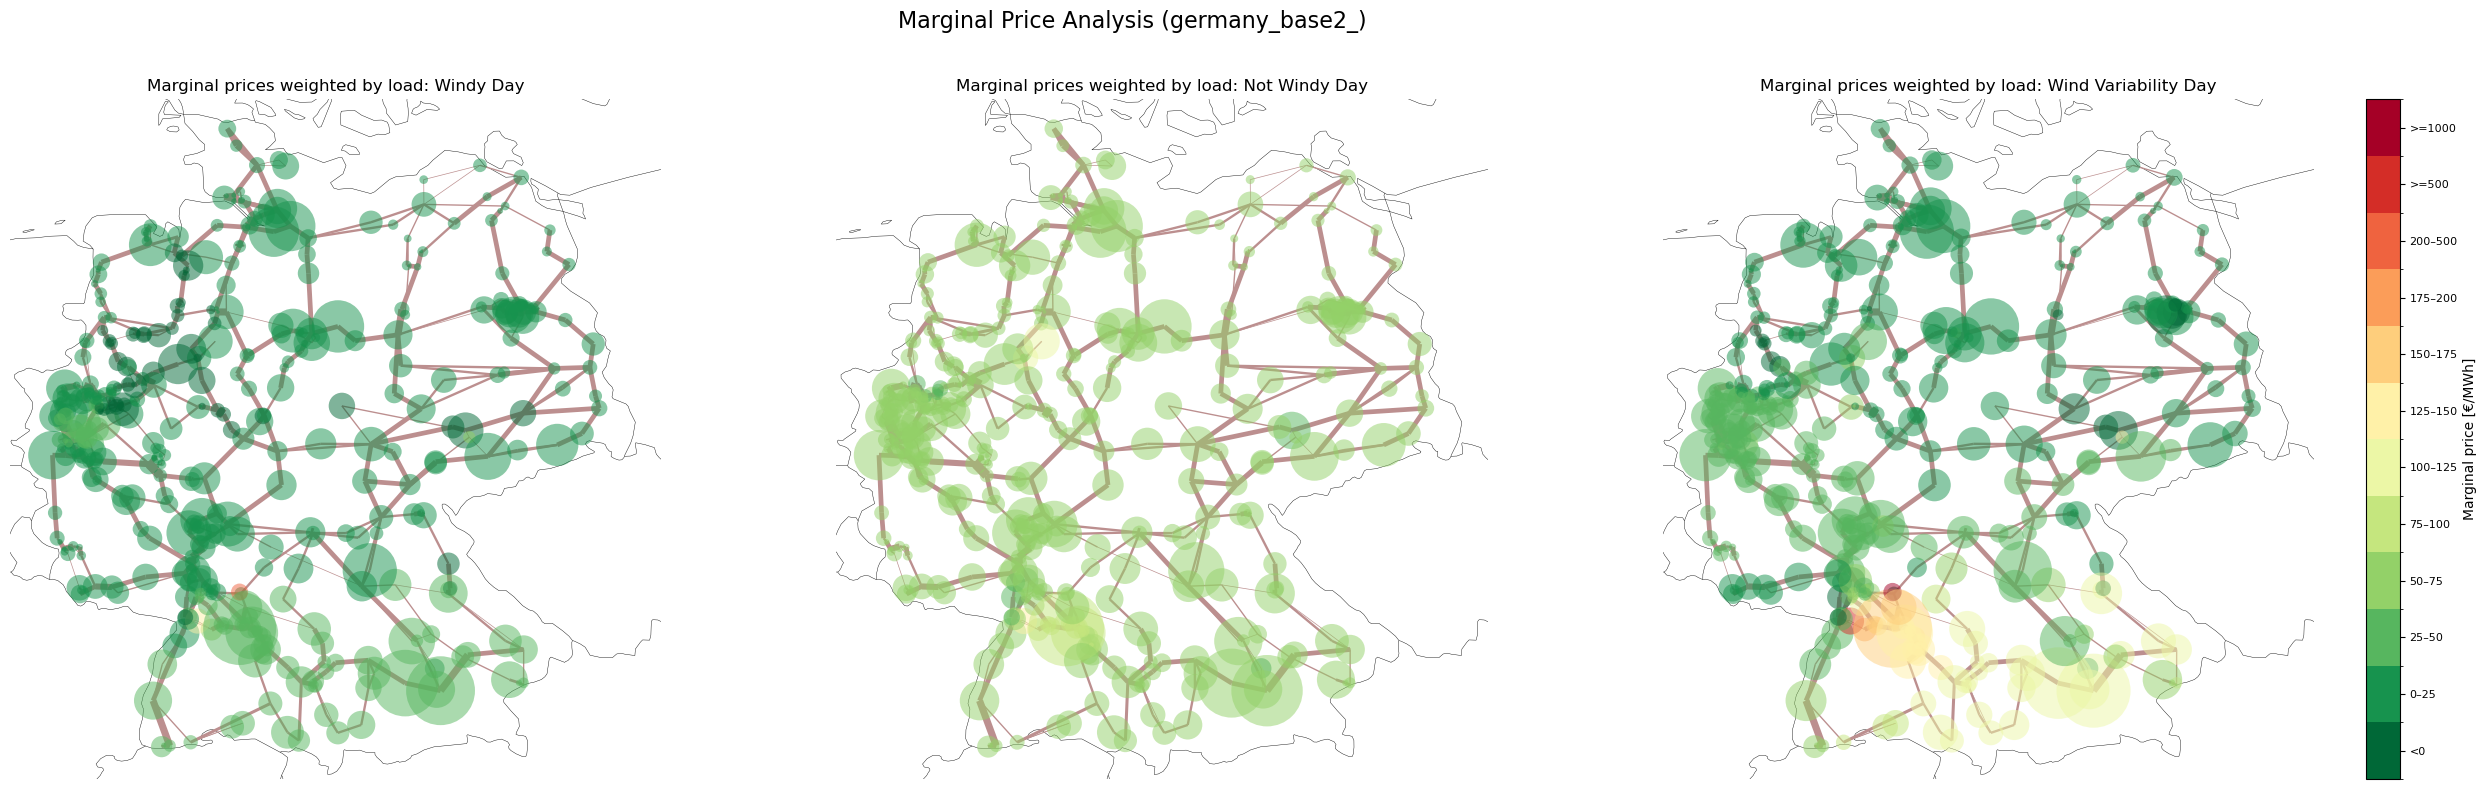

In [12]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Marginal Price Analysis ({folder})", fontsize=16)

# --- Define the normalization for the color map ---
NORMAL_PRICE = 93.15
HIGH_PRICE_THRESHOLD = 10000.01
GLOBAL_MIN = -32.34203267754546

vmin = GLOBAL_MIN
vmax = HIGH_PRICE_THRESHOLD

# Adjust vmin and vmax to ensure vcenter is not at the boundary
if vmin >= NORMAL_PRICE:
    vmin = NORMAL_PRICE - 1
if vmax <= NORMAL_PRICE:
    vmax = NORMAL_PRICE + 1

from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm

# Discrete bins with denser resolution in the green area below 200 €/MWh
bins = [vmin, 0, 25, 50, 75, 100, 125, 150, 175, 200, 500, 1000, vmax]
bins = sorted(set(b for b in bins if vmin <= b <= vmax))
if len(bins) < 2:
    bins = [vmin, vmax]

marginal_price_norm = BoundaryNorm(bins, ncolors=plt.get_cmap("RdYlGn_r").N, clip=False)

# Use the same colormap, but the BoundaryNorm makes it appear in bins
cmap = plt.get_cmap('RdYlGn_r').copy()


# --- Helper Function to Plot Network with Average Loading ---
def plot_marginal_prices(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    # Calculate load at each bus by summing all loads attached to the same bus.
    bus_load = (
        n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
        .reindex(columns=n.buses.index, fill_value=0.0)
    )
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    bus_load_at_peak = bus_load.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=bus_load_at_peak / 6000,
        bus_colors=peak_prices,
        bus_cmap=cmap,
        bus_cmap_norm=marginal_price_norm,
        bus_alpha=0.5,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )
    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_marginal_prices(n, axes[i], "Marginal prices weighted by load: " + n.name + " Day")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print(f"Peak marginal price range: {peak_prices.min():.2f} to {peak_prices.max():.2f} €/MWh")
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Add a discrete colorbar that works like a legend for price ranges.
bus_mappable = ScalarMappable(norm=marginal_price_norm, cmap=cmap)
bus_mappable.set_array([])
cbar_bus = fig.colorbar(bus_mappable, ax=list(axes), orientation='vertical', fraction=0.02, pad=0.02)

# Put more ticks in the low-price area and keep the labels readable.
tick_edges = [vmin, 0, 25, 50, 75, 100, 125, 150, 175, 200, 500, 1000, vmax]
tick_edges = sorted(set(b for b in tick_edges if vmin <= b <= vmax))
if len(tick_edges) < 2:
    tick_edges = [vmin, vmax]

labels = []
for lower, upper in zip(tick_edges[:-1], tick_edges[1:]):
    if upper <= 0:
        labels.append(f"<{int(upper)}")
    elif lower < 0 < upper:
        labels.append(f"<{int(upper)}")
    elif upper >= 1000:
        labels.append(f">={int(lower)}")
    else:
        labels.append(f"{int(lower)}–{int(upper)}")

# Use midpoints so the tick labels sit in the middle of each color band.
midpoints = [(a + b) / 2.0 for a, b in zip(tick_edges[:-1], tick_edges[1:])]
cbar_bus.set_ticks(midpoints)
cbar_bus.set_ticklabels(labels)
cbar_bus.ax.tick_params(labelsize=8)
cbar_bus.set_label('Marginal price [€/MWh]')

save_fig(fig, "marginal_prices_weighted.png")

Network: Windy
count    24.000000
mean     12.746301
std       3.766979
min       6.897406
25%       8.355151
50%      13.866767
75%      15.923575
max      17.815818

Network: Not Windy
count    24.000000
mean     52.031960
std       8.602736
min      32.014777
25%      45.409893
50%      56.528869
75%      57.839590
max      59.573043

Network: Wind Variability
count    24.000000
mean     46.482411
std       5.505754
min      34.490078
25%      46.578338
50%      47.136904
75%      49.208410
max      53.749774

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/average_marginal_prices.png


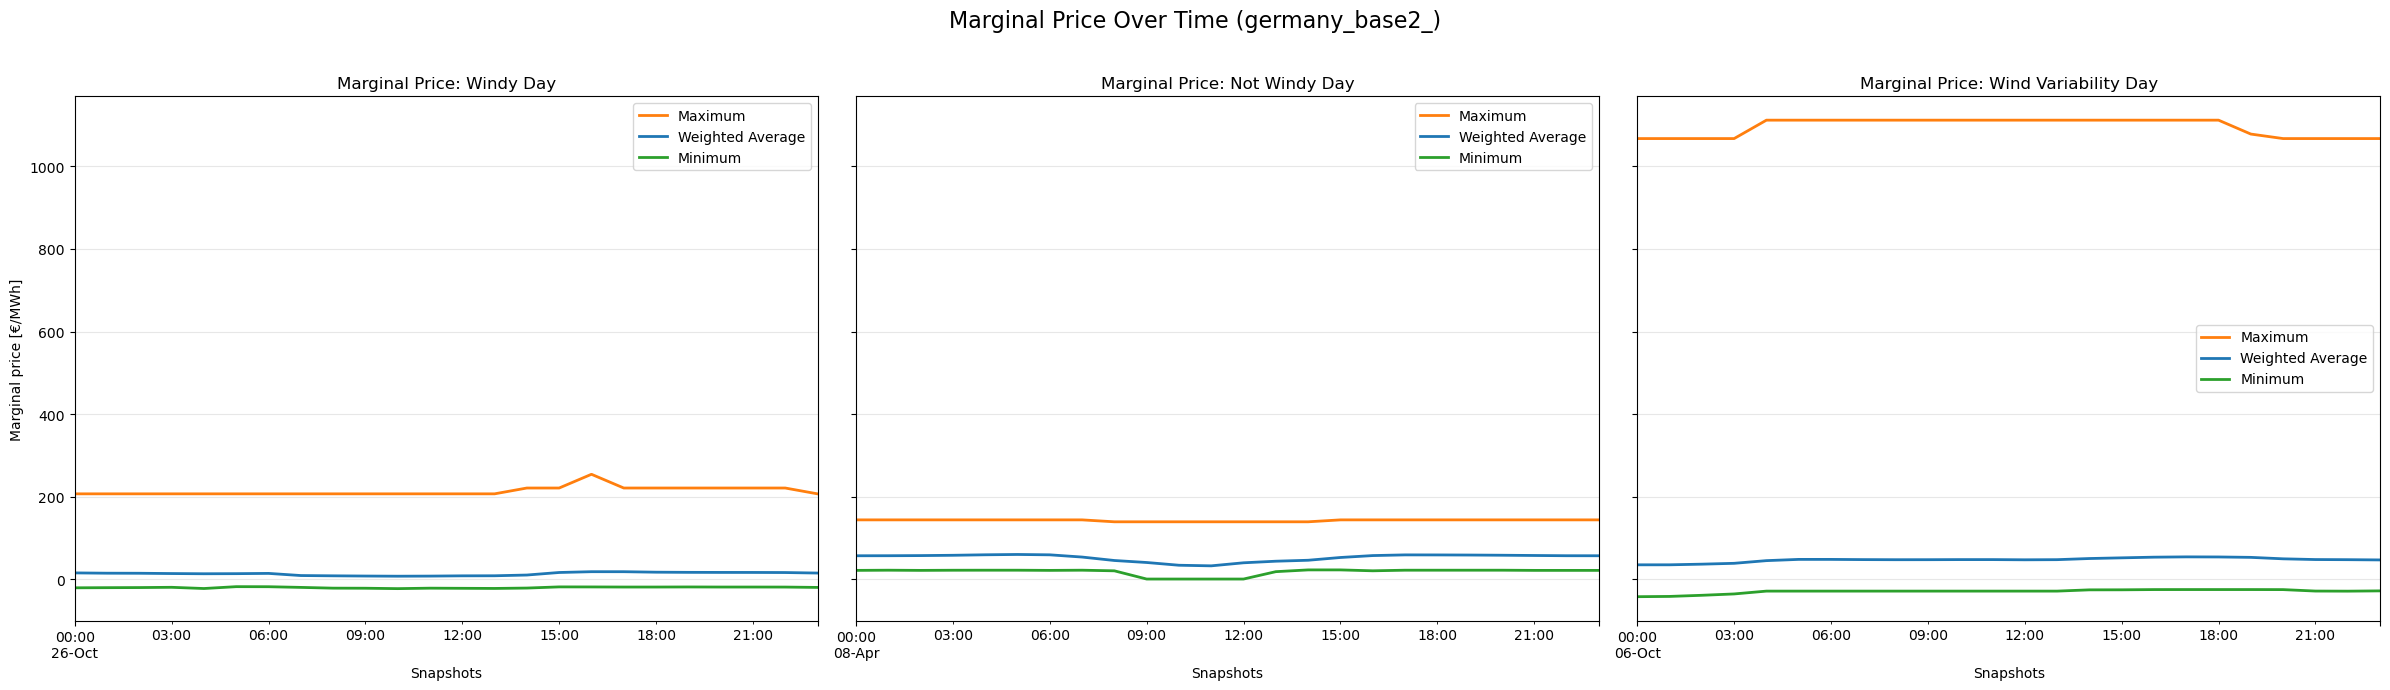

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle(f"Marginal Price Over Time ({folder})", fontsize=16)

for ax, network in zip(axes, [n1, n2, n3]):
    if network.buses_t.marginal_price.empty:
        avg_marginal_price = pd.Series(0.0, index=network.snapshots)
        min_marginal_price = pd.Series(0.0, index=network.snapshots)
        max_marginal_price = pd.Series(0.0, index=network.snapshots)
        log_print(f"No marginal price data found for {network.name}.")
    else:
        # Calculate load-weighted average marginal price
        prices = network.buses_t.marginal_price
        # Aggregate loads per bus
        bus_loads = network.loads_t.p_set.T.groupby(network.loads.bus).sum().T
        # Ensure bus_loads has the same columns as prices, filling missing with 0
        bus_loads = bus_loads.reindex(columns=prices.columns, fill_value=0.0)
        
        total_load = bus_loads.sum(axis=1)
        # Avoid division by zero for snapshots with no load
        weighted_avg_price = (prices * bus_loads).sum(axis=1) / total_load.where(total_load != 0, 1)
        
        avg_marginal_price = weighted_avg_price
        min_marginal_price = network.buses_t.marginal_price.min(axis=1)
        max_marginal_price = network.buses_t.marginal_price.max(axis=1)
    
    max_marginal_price.plot(ax=ax, color="tab:orange", lw=2)
    avg_marginal_price.plot(ax=ax, color="tab:blue", lw=2)
    min_marginal_price.plot(ax=ax, color="tab:green", lw=2)
   
    ax.set_title(f"Marginal Price: {network.name} Day" )
    ax.set_xlabel("Snapshots")
    ax.set_ylabel("Marginal price [€/MWh]")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(["Maximum", "Weighted Average", "Minimum"])

    log_print("=" * 70)
    log_print(f"Network: {network.name}")
    log_print(avg_marginal_price.describe().to_string())
    log_print("=" * 70)
    log_print("")

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "average_marginal_prices.png")

### Load shedding

 Network: Windy
  Average loading across all lines: 15.52%
  Max average loading: 66.46%
  Lines with >60% avg loading: 4
  Lines with >70% avg loading: 0

 Network: Not Windy
  Average loading across all lines: 11.85%
  Max average loading: 52.28%
  Lines with >60% avg loading: 0
  Lines with >70% avg loading: 0

 Network: Wind Variability
  Average loading across all lines: 17.02%
  Max average loading: 62.65%
  Lines with >60% avg loading: 1
  Lines with >70% avg loading: 0

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/load_shedding.png


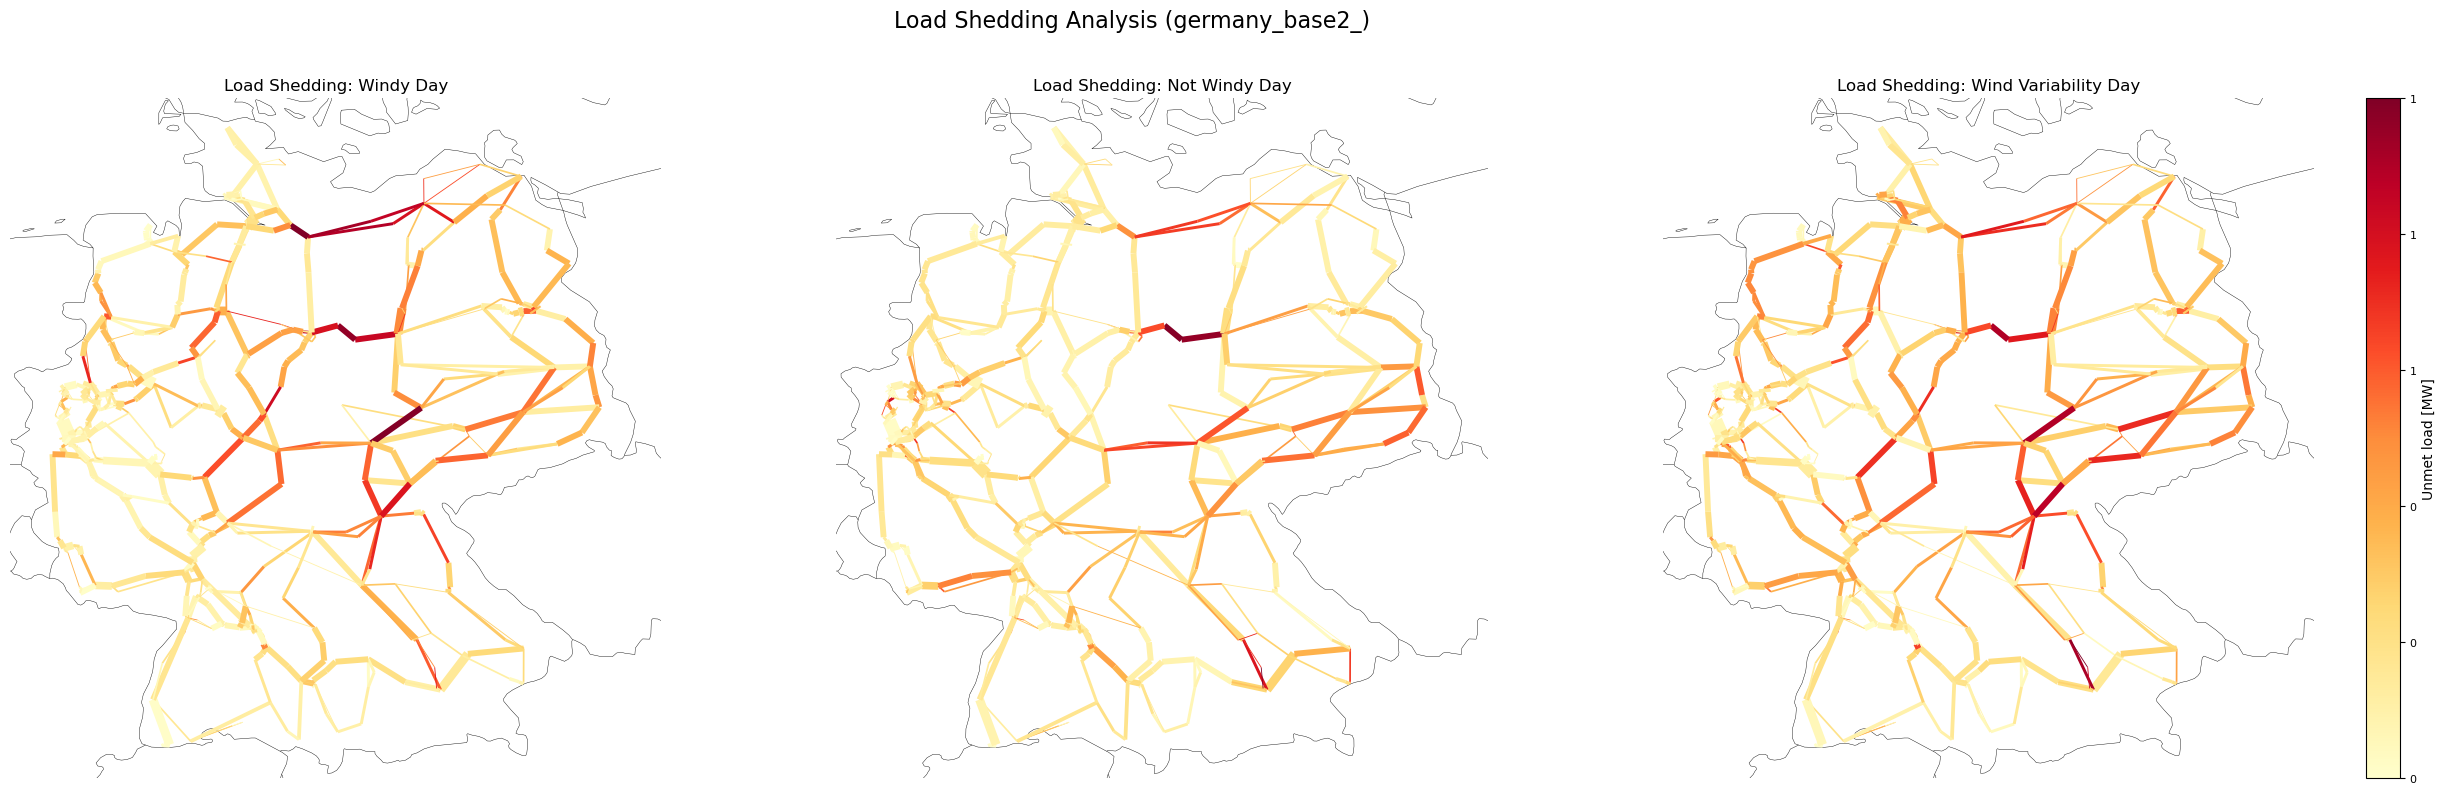

In [18]:
# --- Create enhanced visualization ---
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Load Shedding Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
# Collect unmet-load maxima to build a shared colorbar across subplots
unmet_max_list = []

def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        log_print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"]).sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]

    # Track the maximum unmet load for this network for a shared colorbar later
    unmet_max_list.append(unmet_load_at_snapshot.max())

    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=unmet_load_at_snapshot/2000,
        bus_alpha=0.7,
        bus_colors=unmet_load_at_snapshot,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 800,
        link_width=n.links.p_nom / 800 if not n.links.empty else 0,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], "Load Shedding: " + n.name + " Day")
    log_print("=" * 70)
    log_print(f" Network: {n.name}")
    log_print(f"  Average loading across all lines: {avg_loading.mean():.2%}")
    log_print(f"  Max average loading: {avg_loading.max():.2%}")
    log_print(f"  Lines with >60% avg loading: {(avg_loading > 0.6).sum()}")
    log_print(f"  Lines with >70% avg loading: {(avg_loading > 0.7).sum()}")
    log_print("=" * 70)
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Create a shared colorbar for bus colors (unmet load) using the same colormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
max_unmet = max(unmet_max_list) if unmet_max_list else 1.0
# Ensure a non-zero vmax to avoid division-by-zero in Normalize
vmax_unmet = max(max_unmet, 1.0)
bus_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=vmax_unmet), cmap=plt.get_cmap("YlOrRd"))
bus_mappable.set_array([])

cbar_unmet = fig.colorbar(bus_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
# Choose readable ticks with slightly more resolution at low values
ticks = np.unique(np.concatenate(([0.0], np.linspace(0.0, vmax_unmet, num=6))))
cbar_unmet.set_ticks(ticks)
cbar_unmet.set_ticklabels([f"{t:.0f}" for t in ticks])
cbar_unmet.ax.tick_params(labelsize=8)
cbar_unmet.set_label('Unmet load [MW]')

save_fig(fig, "load_shedding.png")

In [15]:
n.links.groupby("carrier").sum()

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,679.460093,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,2213.758325,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,3436.536930,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,3507.400817,0


##### Offshore Wind Curtailment


#### Parameter Documentation for New Curtailment Function

**Parameters Used:**

1. **`generators.p_nom`** (static, MW) — Installed/nameplate capacity
   - *Why:* Represents the fixed maximum power the generator can produce (unless extendable).
   - *Used when:* Generator capacity was not optimized.

2. **`generators.p_nom_opt`** (output, MW) — Optimized capacity after solving
   - *Why:* After optimization, if `p_nom_extendable=True`, this holds the actual capacity built. For post-solve analysis, we should use this.
   - *Fallback:* If `p_nom_opt` is NaN, we fall back to `p_nom`.
   - **This is the key fix:** The old function ignored optimization, always using `p_nom`.

3. **`generators_t.p_max_pu`** (time series, per unit, 0-1) — Maximum output availability factor
   - *Why:* For renewables, this is the capacity factor from weather (wind speed, solar irradiance). For conventional plants, it's the de-rating factor (maintenance, forced outages, etc.).
   - *Formula:* Available Power[t] = `p_max_pu[t]` × `p_nom_eff`

4. **`generators_t.p`** (time series, MW) — Actual dispatched power (solver output)
   - *Why:* This is what was actually generated. Curtailment = Available − Dispatched.

5. **`generators.carrier`** (string) — Energy carrier type (e.g., 'onwind', 'offwind-ac', 'solar')
   - *Why:* Allows filtering/grouping by technology type for separate analysis.

**The Curtailment Equation:**

$$\text{Curtailed Power}[t] = \max\left(0, \, p\_max\_pu[t] \times p\_nom\_eff \, - \, p[t] \right)$$

where $p\_nom\_eff = p\_nom\_opt$ if extendable (and not NaN), otherwise $p\_nom$.


In [16]:
def plot_curtailment(n, carrier, ax):
    # Time-series available / dispatched / curtailed aggregated by carrier
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = (p_available_by_carrier - p_by_carrier).clip(lower=0)

    # Use friendly display name for the title, but keep the legend generic.
    carrier_display = carrier_label(carrier)
    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    # Build a dataframe for plotting while keeping the legend labels generic.
    p_df = pd.DataFrame(
        {
            "dispatched": p_by_carrier[carrier],
            "curtailed": p_curtailed_by_carrier[carrier],
            "available": p_available_by_carrier[carrier],
        }
    )
    p_df["capacity"] = capacity

    # Plot stacked dispatched + curtailed area, then available and capacity lines
    p_df[["dispatched", "curtailed"]].plot(kind="area", ax=ax, lw=0, legend=False)
    p_df[["available", "capacity"]].plot(ax=ax, legend=False)

    # Compute totals for logging
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()

    # Axis formatting and explicit generic legend handles.
    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df["capacity"].max() * 1.1 if hasattr(p_df["capacity"], "max") else None])
    ax.set_title(f"{carrier_display} Curtailment: {n.name} Day")

    legend_handles = [
        Patch(facecolor="tab:blue", edgecolor="none", label="dispatched"),
        Patch(facecolor="tab:orange", edgecolor="none", label="curtailed"),
        Line2D([0], [0], color="tab:green", lw=2, label="available"),
        Line2D([0], [0], color="tab:red", lw=2, label="capacity"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.12), frameon=False)

    # Log summary using display-name
    log_print("=" * 70)
    log_print(f"Network: {n.name}")
    log_print(f"{carrier_display} capacity MW: {n.generators.groupby('carrier')['p_nom'].sum().get(carrier):.2f}")
    log_print(f"Total available (MWh): {tot_av:.2f}")
    log_print(f"Total dispatched (MWh): {tot_disp:.2f}")
    log_print(f"Total curtailed (MWh): {tot_cur:.2f}")
    log_print(f"Curtailed fraction: {tot_cur / tot_av if tot_av else float('nan'):.2f}")
    log_print("=" * 70)
    log_print("")

#### offwind

Network: Windy
Offshore wind (AC) capacity MW: 11163.74
Total available (MWh): 236217.48
Total dispatched (MWh): 37499.90
Total curtailed (MWh): 198717.58
Curtailed fraction: 0.84

Network: Not Windy
Offshore wind (AC) capacity MW: 11163.74
Total available (MWh): 8316.63
Total dispatched (MWh): 8316.62
Total curtailed (MWh): 0.01
Curtailed fraction: 0.00

Network: Wind Variability
Offshore wind (AC) capacity MW: 11163.74
Total available (MWh): 173568.76
Total dispatched (MWh): 69168.05
Total curtailed (MWh): 104400.71
Curtailed fraction: 0.60

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/offwind_curtailment.png


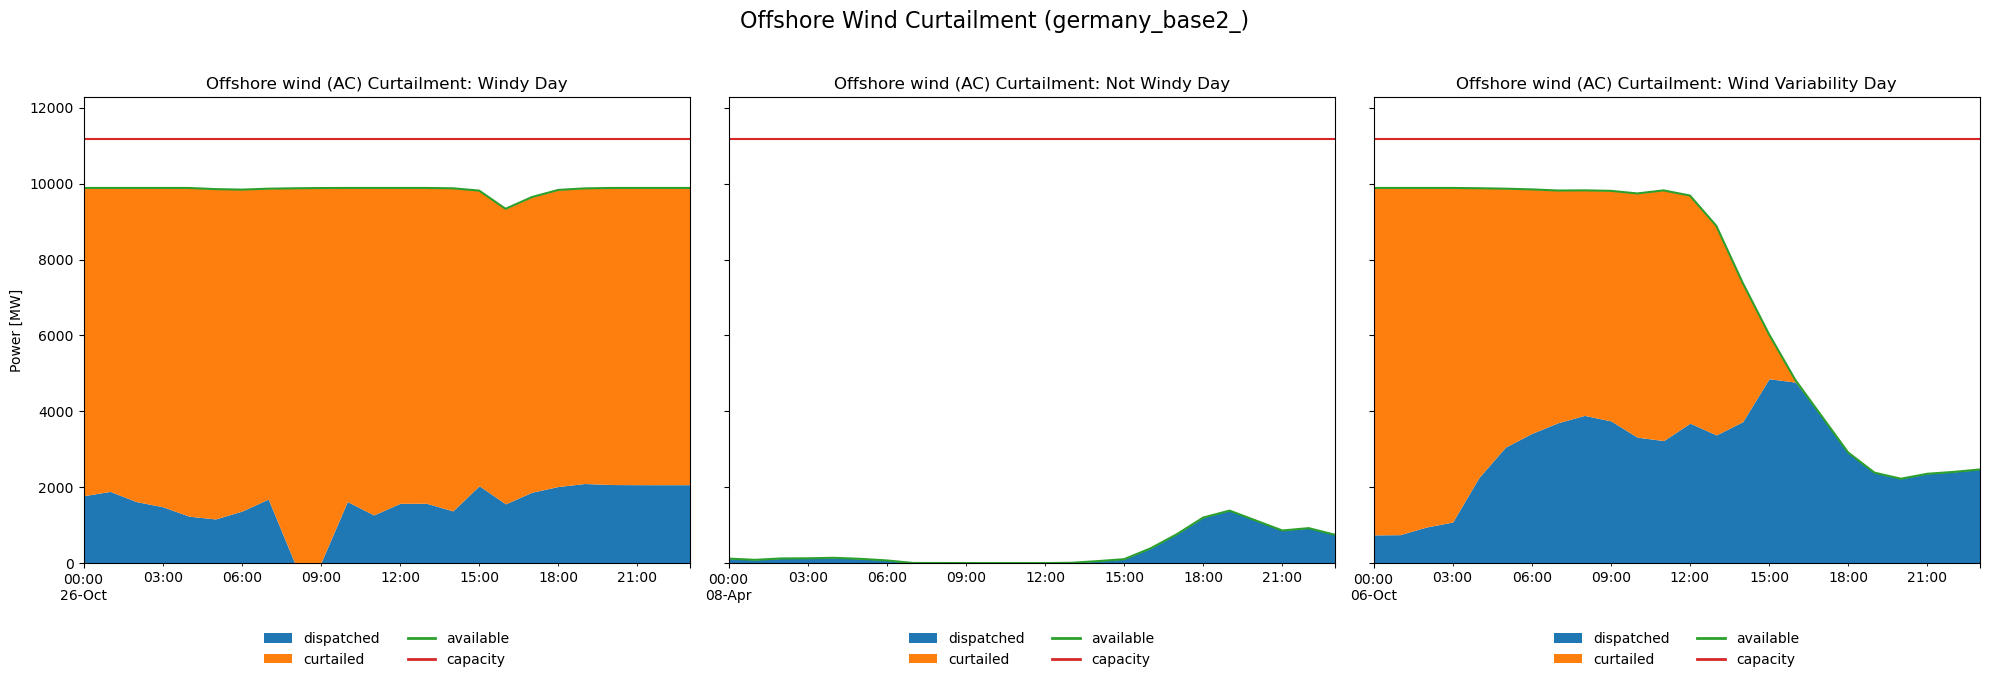

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle(f"Offshore Wind Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "offwind_curtailment.png")

#### onwind

Network: Windy
Onshore wind capacity MW: 73332.07
Total available (MWh): 1520776.20
Total dispatched (MWh): 891757.66
Total curtailed (MWh): 629018.54
Curtailed fraction: 0.41

Network: Not Windy
Onshore wind capacity MW: 73332.07
Total available (MWh): 49435.40
Total dispatched (MWh): 49435.00
Total curtailed (MWh): 0.40
Curtailed fraction: 0.00

Network: Wind Variability
Onshore wind capacity MW: 73332.07
Total available (MWh): 804830.80
Total dispatched (MWh): 627686.43
Total curtailed (MWh): 177144.37
Curtailed fraction: 0.22

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/onwind_curtailment.png


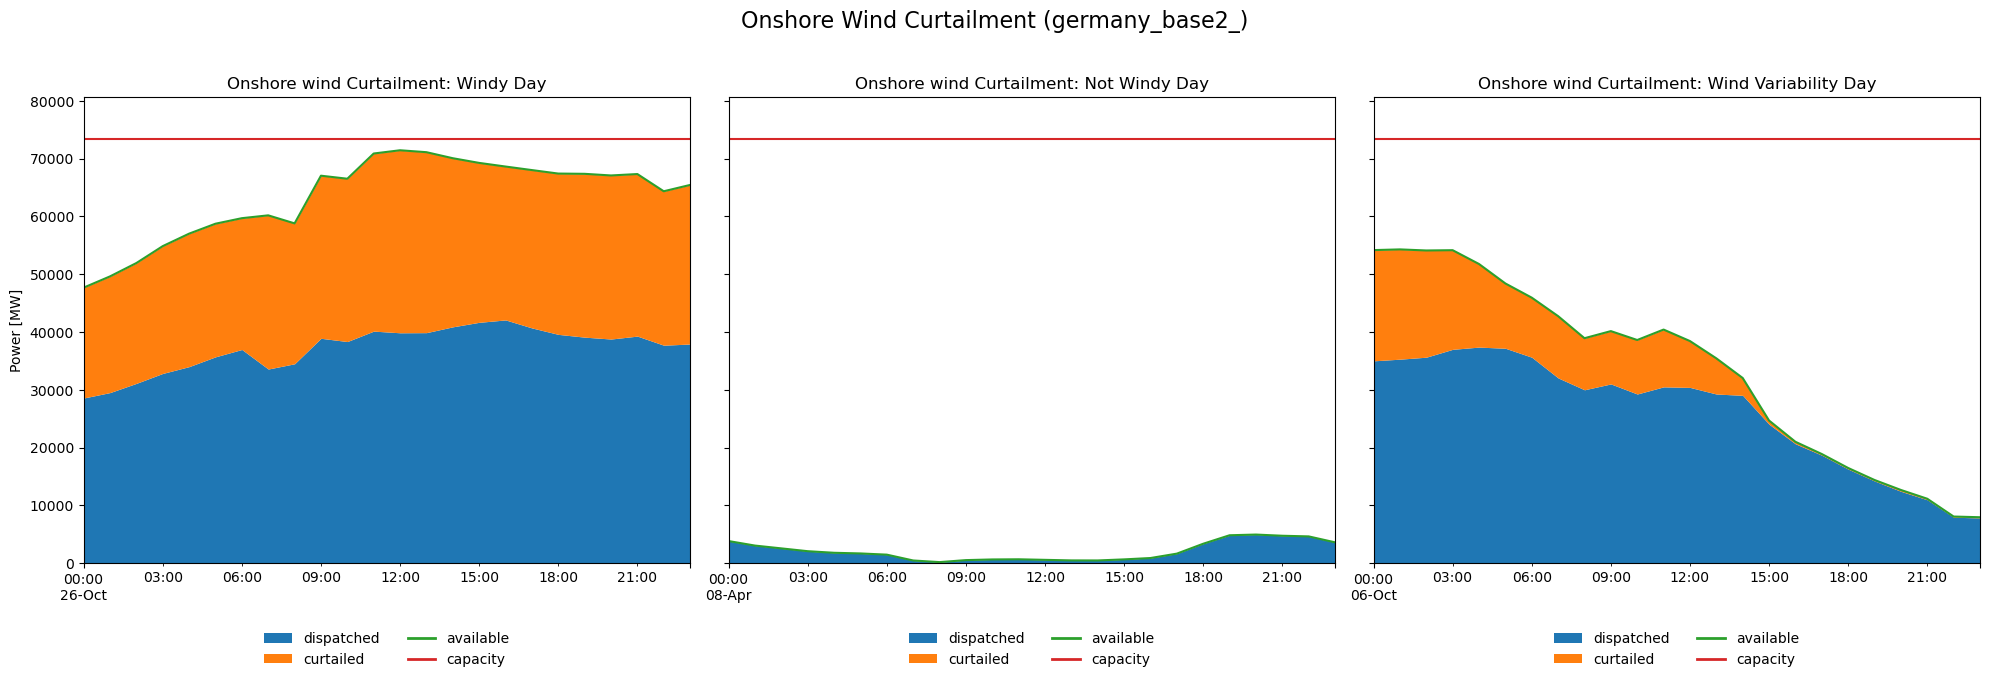

In [252]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle(f"Onshore Wind Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "onwind_curtailment.png")

#### solar

Network: Windy
Solar PV capacity MW: 86408.00
Total available (MWh): 121780.28
Total dispatched (MWh): 109658.49
Total curtailed (MWh): 12121.79
Curtailed fraction: 0.10

Network: Not Windy
Solar PV capacity MW: 86408.00
Total available (MWh): 438181.16
Total dispatched (MWh): 438048.79
Total curtailed (MWh): 132.37
Curtailed fraction: 0.00

Network: Wind Variability
Solar PV capacity MW: 86408.00
Total available (MWh): 90121.28
Total dispatched (MWh): 83814.86
Total curtailed (MWh): 6306.42
Curtailed fraction: 0.07

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/solar_curtailment.png


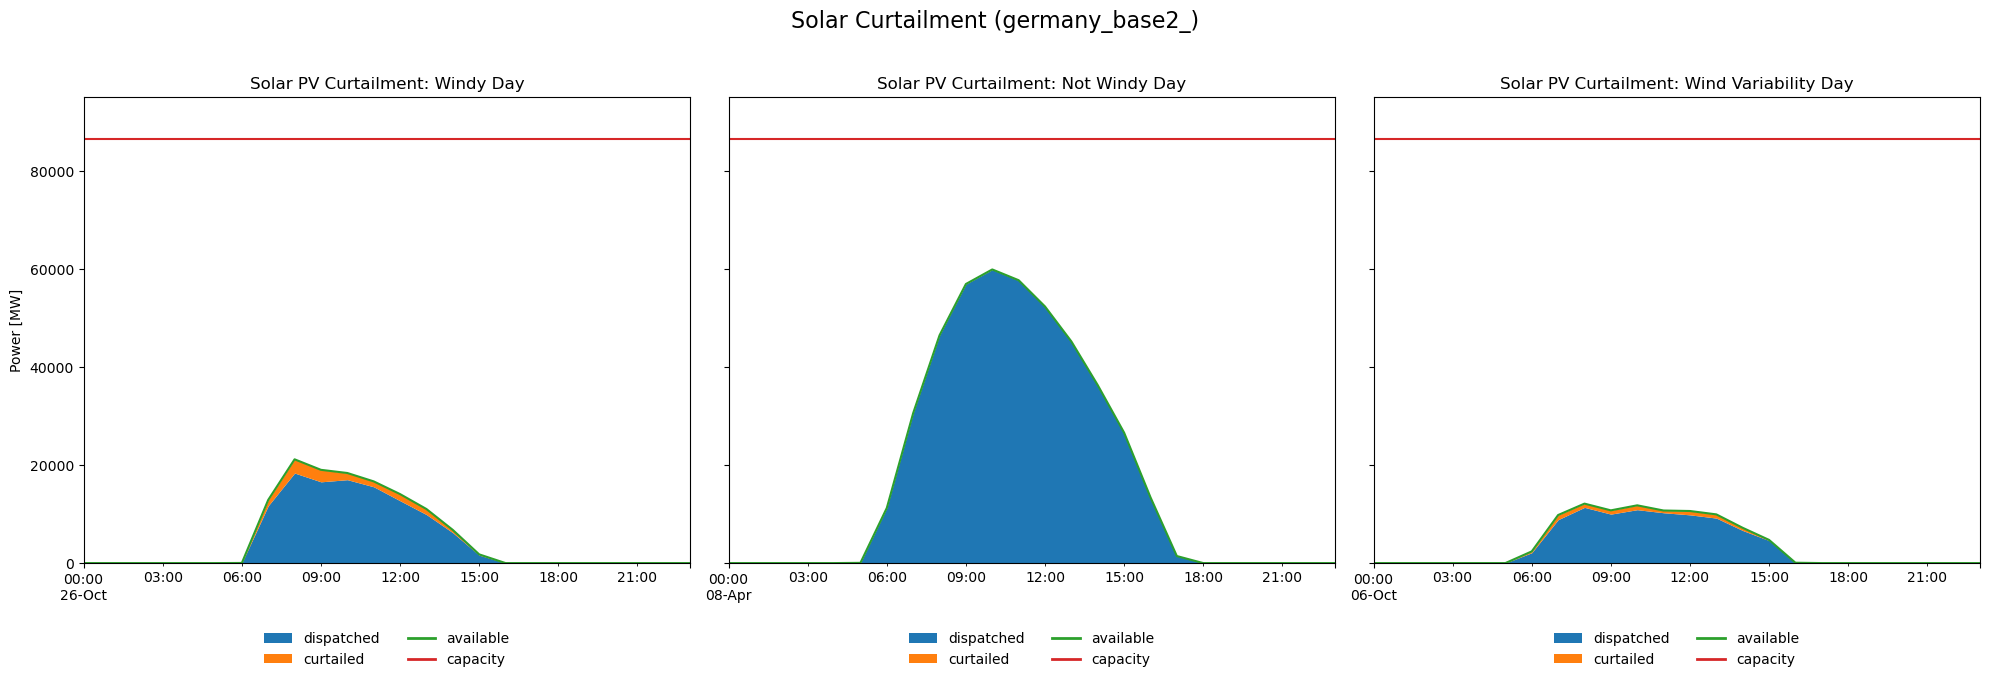

In [253]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle(f"Solar Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "solar", axes[0])
plot_curtailment(n2, "solar", axes[1])
plot_curtailment(n3, "solar", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "solar_curtailment.png")

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/power_dispatch.png


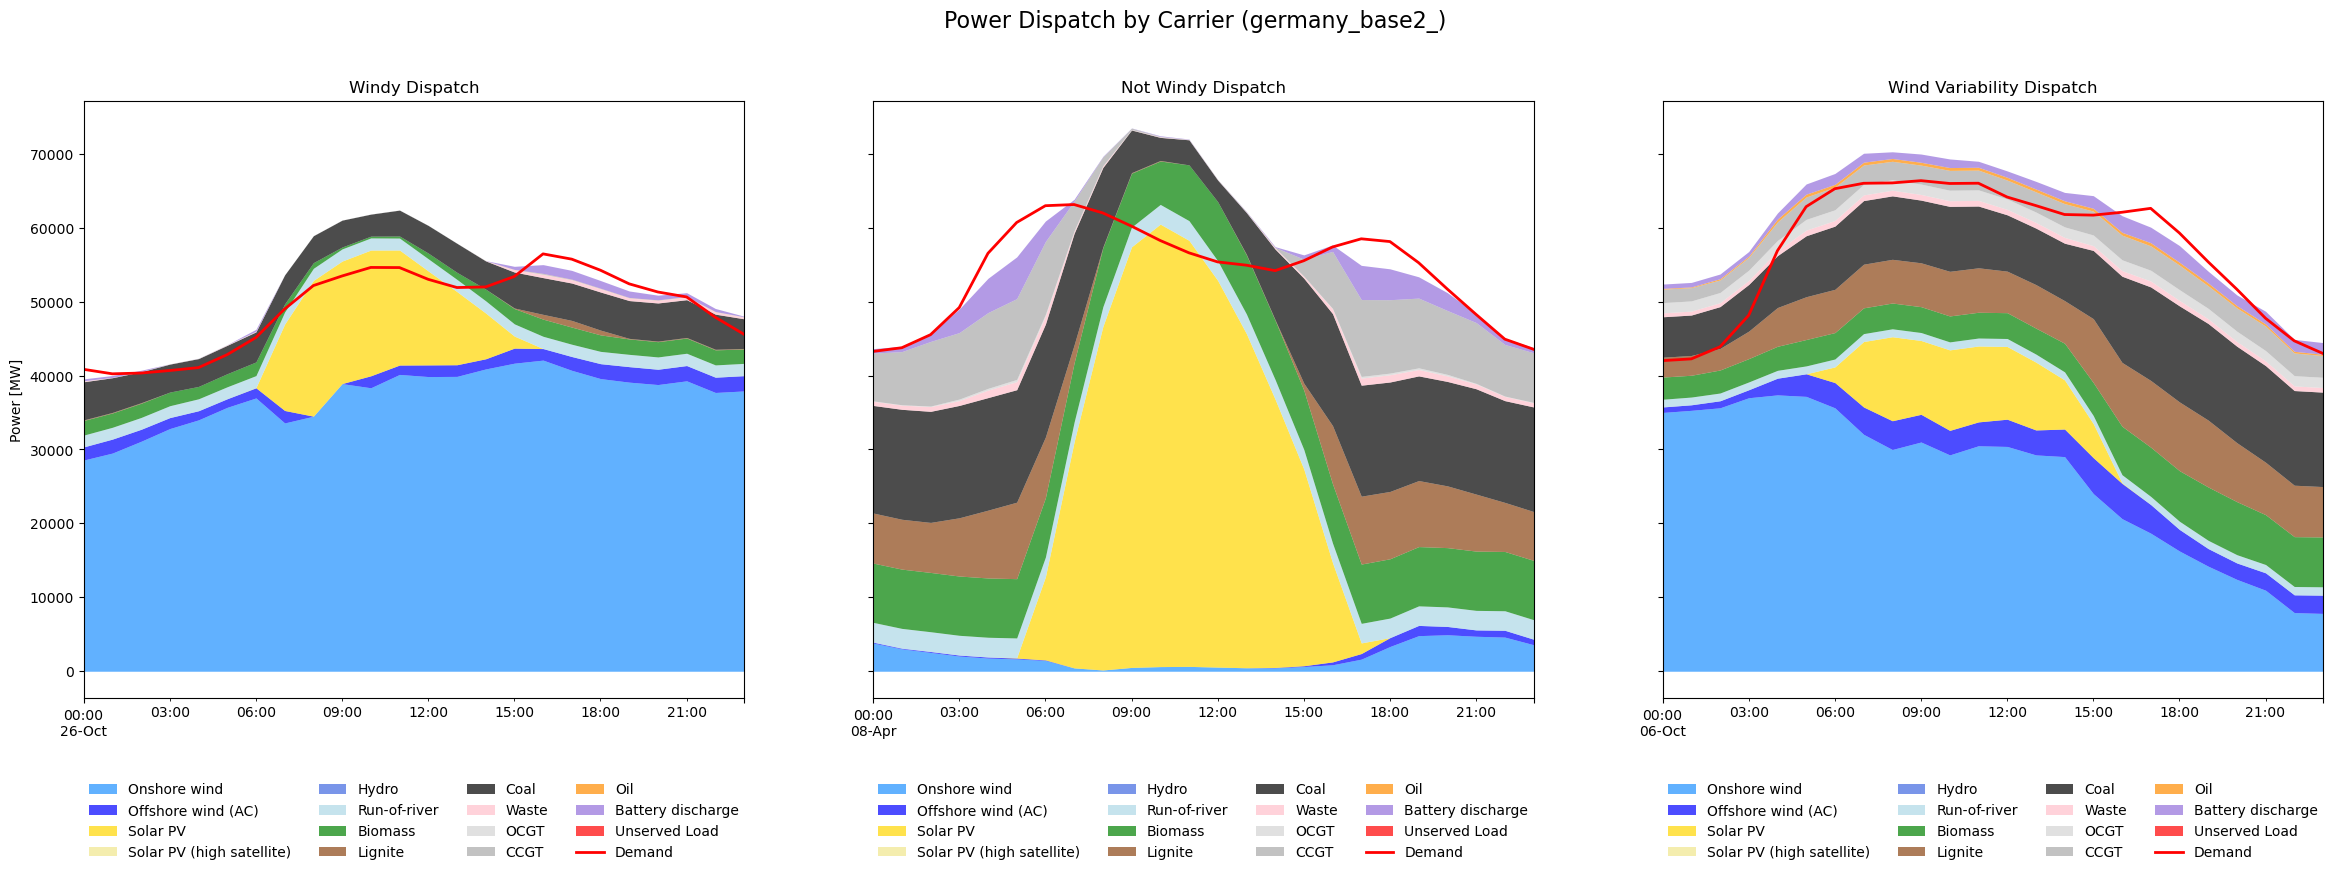

In [254]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9), sharey=True)
fig.suptitle(f"Power Dispatch by Carrier ({folder})", fontsize=16)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    #"geothermal": "firebrick",
    "battery discharge": "mediumpurple",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", #"geothermal",
    # Conventional
    "lignite", "coal", "waste",
    "OCGT", "CCGT", "oil",
    # Storage
    "battery discharge",
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]
    p_by_carrier.columns = [carrier_label(col) for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    scenario_title = n.name

    real_data = pd.read_csv(
        f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv",
        index_col=0,
        parse_dates=True,
    )
    real_data.index = pd.to_datetime(real_data.index)
    # Align to the network snapshots so missing hours do not break the plot
    demand_real = real_data["grid load"].reindex(n.snapshots)
    demand_real.name = "Actual Demand"
    # Shift real data by two hours
    if n.name == "Windy":
        demand_real = demand_real.shift(-1)
    else:
        demand_real = demand_real.shift(-2)
    #demand_real.plot(ax=ax, color="red", linestyle="--", lw=2, label="Actual Demand")

    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "power_dispatch.png")

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/power_dispatch_wind-only.png


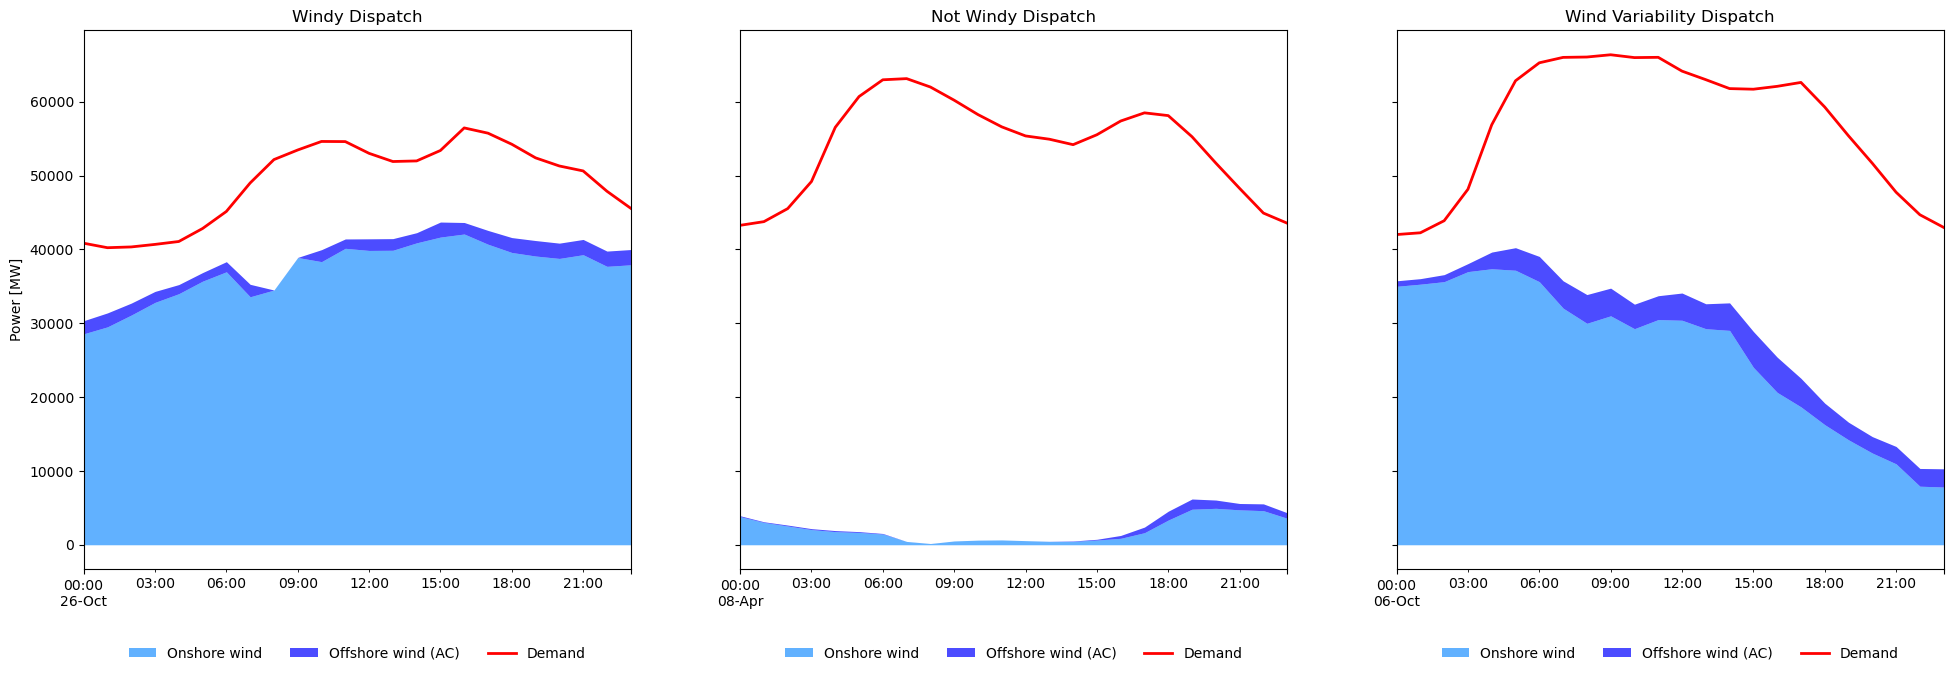

In [255]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)


cols = [
    # Renewables
    "onwind", "offwind-ac", 
]


# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

save_fig(fig, "power_dispatch_wind-only.png")

Plotting 'Windy' network at time 2025-10-26 12:00:00 with peak curtailment 41293.72 MW
Plotting 'Not Windy' network at time 2025-04-08 11:00:00 with peak curtailment 57.49 MW
Plotting 'Wind Variability' network at time 2025-10-06 00:00:00 with peak curtailment 28323.28 MW
Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/curtailment_map_by_carrier_pie.png


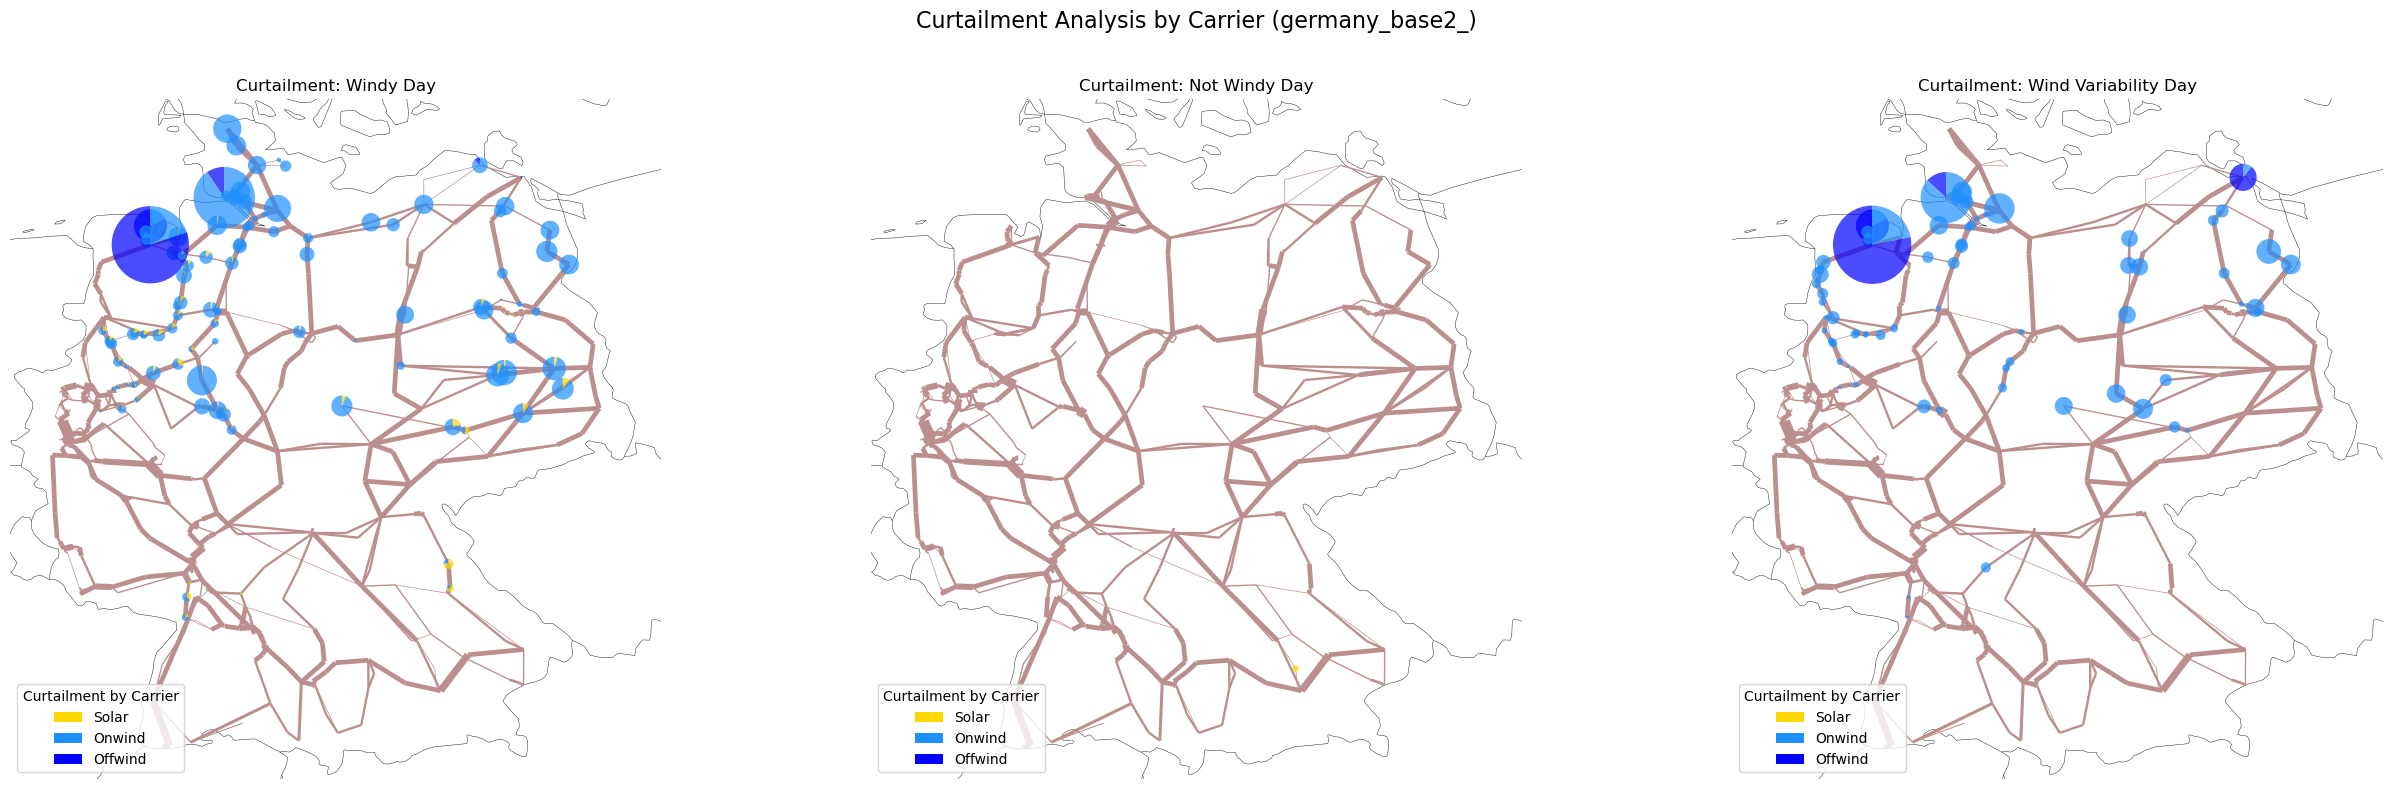

In [256]:
# --- Create enhanced visualization for curtailment ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Curtailment Analysis by Carrier ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Curtailment ---
def plot_network_curtailment(n, ax, title):
    # Effective capacity: p_nom_opt if available, otherwise p_nom
    p_nom_eff = n.generators.p_nom_opt.where(n.generators.p_nom_opt.notna(), n.generators.p_nom)
    
    # Time-series of available power
    p_available = n.generators_t.p_max_pu.multiply(p_nom_eff)
    
    # Time-series of dispatched power
    p_dispatched = n.generators_t.p
    
    # Time-series of curtailed power
    p_curtailed = (p_available - p_dispatched).clip(lower=0)

    # Define carrier groups
    carrier_groups = {
        'solar': ['solar', 'solar-hsat'],
        'onwind': ['onwind'],
        'offwind': ['offwind-ac', 'offwind-dc', 'offwind-float']
        #'conventional': ['lignite', 'coal', 'oil', 'OCGT', 'CCGT', 'biomass', 'waste', 'geothermal', 'hydro', 'ror']
    }
    
    # Invert carrier_groups to map from carrier to group name
    carrier_to_group = {carrier: group for group, carriers in carrier_groups.items() for carrier in carriers}
    
    # Map generator carriers to the defined groups
    gen_groups = n.generators.carrier.map(carrier_to_group).rename('group')

    # Aggregate curtailment by bus and by carrier group
    curtailment_by_bus_group_time = p_curtailed.T.groupby([n.generators.bus, gen_groups]).sum().T
    
    # Total curtailment for finding the worst snapshot
    total_curtailment_time = p_curtailed.sum(axis=1)
    worst_curtailment_snapshot = total_curtailment_time.idxmax()
    
    # Curtailment at the worst snapshot, aggregated by bus and group
    curtailment_snapshot = curtailment_by_bus_group_time.loc[worst_curtailment_snapshot]
    
    # Define colors for carrier groups
    group_colors = {
        'solar': 'gold',
        'onwind': 'dodgerblue',
        'offwind': 'blue'
        #'conventional': 'darkgray'
    }
    
    log_print(f"Plotting '{n.name}' network at time {worst_curtailment_snapshot} with peak curtailment {total_curtailment_time.max():.2f} MW")

    bus_size_factor = 30000

    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=curtailment_snapshot / bus_size_factor,
        bus_colors=group_colors,
        bus_alpha=0.7,
        #line_colors=(n.lines_t.p0.abs() / n.lines.s_nom).mean(),
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000 if not n.links.empty else 0,
    )
    
    # Create a legend for the carrier groups
    legend_handles = [Patch(facecolor=color, label=group.capitalize()) for group, color in group_colors.items()]
    ax.legend(handles=legend_handles, loc='lower left', title='Curtailment by Carrier')


# Plot Curtailment for each network
i = 0
for n in networks.values():
    plot_network_curtailment(n, axes[i], "Curtailment: " + n.name + " Day")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "curtailment_map_by_carrier_pie.png")

##### Total Energy Production by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/total_energy_production.png

=== Energy Production Summary ===
                            Windy      Not Windy  Wind Variability
Onshore wind        891757.662632   49434.998816     627686.430574
Solar PV            109658.493065  438048.790985      83814.861702
Coal                102874.846124  291254.743196     223876.245631
Biomass              38043.343011  189052.241738     110102.967891
Lignite               2886.891292  124086.081099     149480.514605
CCGT                   235.855601  138389.162877      65857.468318
Run-of-river         39367.558978   63869.595498      26076.924715
Offshore wind (AC)   37499.900053    8316.624031      69168.049141
OCGT                   610.842198    2469.177443      33914.778713
Waste                 3552.284328   12751.476744      16591.156770
Oil                    147.166053       0.684168       7656.838866
Geothermal             512.975335     645.589503  

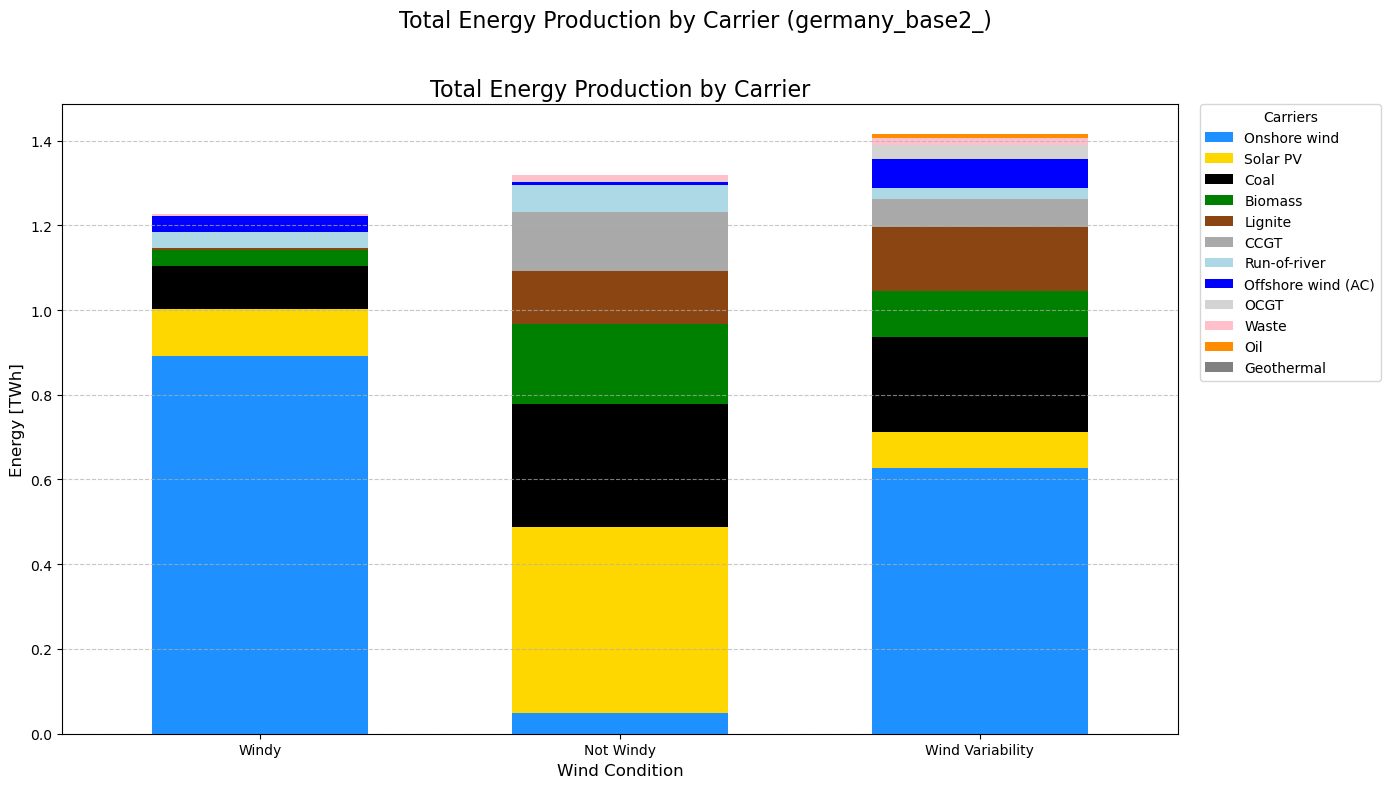

In [257]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]
carrier_keys = list(energy_df.index)
energy_df.index = [carrier_label(carrier) for carrier in carrier_keys]

# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in carrier_keys]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle(f"Total Energy Production by Carrier ({folder})", fontsize=16)

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Wind Condition", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "total_energy_production.png")

# Log energy production summary
log_print("\n=== Energy Production Summary ===")
log_print(energy_df.to_string())
log_print("\n")

In [258]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

log_print("\n=== CO2 Emissions Summary ===")
for n in networks.values():
    log_print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")
log_print("\n")


=== CO2 Emissions Summary ===
Total CO2 emissions at the Windy day: 87488.48 kg CO2
Total CO2 emissions at the Not Windy day: 438356.16 kg CO2
Total CO2 emissions at the Wind Variability day: 414339.49 kg CO2




### Statistics

In [259]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    log_print(n.statistics().to_string())
    log_print("\n")

log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")


=== Network Statistics ===

Network: Windy
                                  Optimal Capacity  Installed Capacity        Supply    Withdrawal  Energy Balance  Transmission  Capacity Factor   Curtailment  Capital Expenditure  Operational Expenditure       Revenue  Market Value
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04  2.358556e+02  0.000000e+00    2.358556e+02       0.00000         0.000319  7.385592e+05         1.066291e+07             1.313263e+04  1.405706e+04     59.600248
            Offshore Wind (AC)        1.116374e+04        1.116374e+04  3.749990e+04  0.000000e+00    3.749990e+04       0.00000         0.139962  1.987176e+05         9.110722e+06             9.378497e+02  1.014350e+03      0.027049
            Onshore Wind              7.333207e+04        7.333207e+04  8.917577e+05  0.000000e+00    8.917577e+05       0.00000         0.506689  6.290185e+05         2.387208e+07             2.223748e+04  4.816603e+06      5.401246
            Open-Cyc

In [260]:
for n in networks.values():

    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

    map=n.explore(
        line_color=avg_loading_n,
        line_width= n.lines.s_nom / 500,
        line_cmap="YlOrRd",
        bus_alpha=0.2,
        line_alpha=0.5,
        bus_color = "lightblue",
    )

    path_to_dir = f"{analysis_dir}/interactive_map_{n.name}.html"
    map.to_html(path_to_dir)

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7df4287f9e50>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x7df4287f9f90>,
  'Line': <matplotlib.collections.LineCollection at 0x7df4287f8190>},
 'flows': {}}

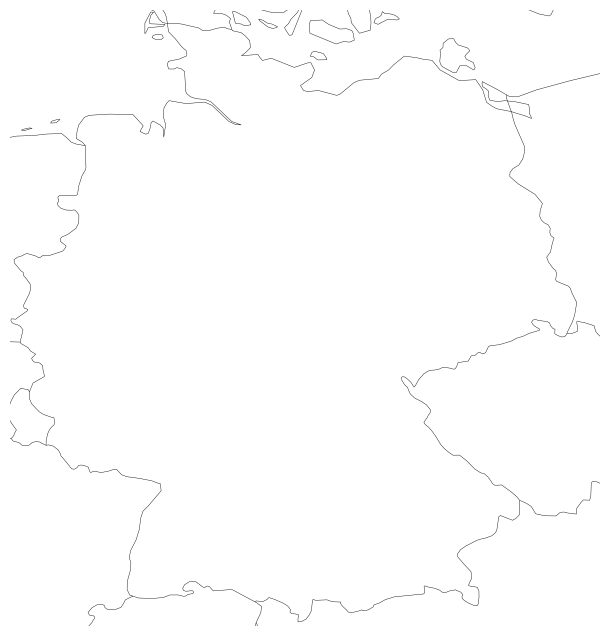

In [261]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth()})


n1.plot(
    ax=axes,
    geomap=True,
    bus_sizes=0,
    line_width=0,
    link_width=0,
)